In [107]:
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pertpy as pt
import scanpy as sc

plt.rcParams["figure.figsize"] = (3, 3)

In [108]:
adata = sc.read_h5ad("/home/icb/alessandro.palma/environment/scFM_density_estimation/project_folder/data/pbmc68k_oversampled/pbmc68k_0.45.h5ad")

Pretend to have a sample (used for FDR) by assigning observations randomly to three categories 

In [109]:
adata.obs["sample_id"] = None
n_control, n_trt = np.unique(adata.obs["treatment"], return_counts=True)[1]
ctr_samples = np.random.randint(0, 2, n_control)
trt_samples = np.random.randint(2, 4, n_trt)

adata.obs.loc[adata.obs.treatment==0, "sample_id"] = ctr_samples
adata.obs.loc[adata.obs.treatment==1, "sample_id"] = trt_samples

adata.obs["sample_id"] = adata.obs["sample_id"].astype("category")

In [110]:
adata.obs["treatment_label"] = adata.obs.treatment.astype(str)
adata.obsm["X_pca"].shape

(65877, 50)

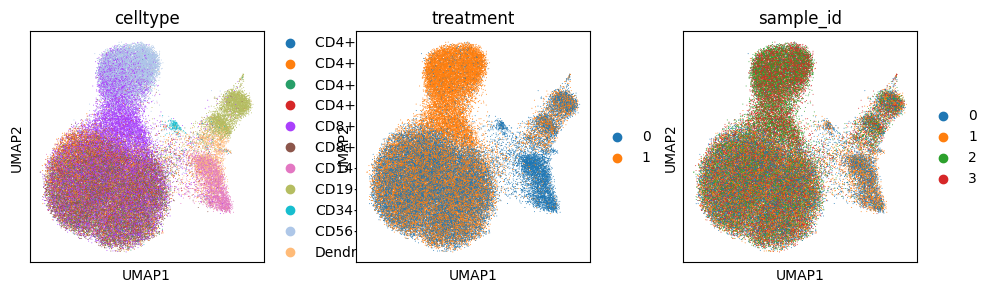

In [111]:
sc.pl.umap(adata, color=["celltype", "treatment", "sample_id"])

In [112]:
milo = pt.tl.Milo()
mdata = milo.load(adata)

In [113]:
milo.make_nhoods(mdata["rna"], prop=0.1)

! Using X_pca as default embedding


There are 4k neighborhoods to which cells are assigned

In [114]:
mdata["rna"].obsm["nhoods"]

<Compressed Sparse Row sparse matrix of dtype 'float32'
	with 225511 stored elements and shape (65877, 4741)>

Every neighborhood has an index cell. 

In [115]:
mdata["rna"][mdata["rna"].obs["nhood_ixs_refined"] != 0].obs[["nhood_ixs_refined", "nhood_kth_distance"]]

,nhood_ixs_refined,nhood_kth_distance
AAACGCACGGTACT,1,1.665295
AAACTTGAGGAGCA,1,1.417195
AAAGAGACGTTACG,1,1.843487
AAAGATCTTATCTC,1,1.456541
AAAGTTTGTATTCC,1,1.292195
...,...,...
TTTAGAGAGAGACG,1,1.499688
TTTAGCTGAACCGT,1,1.654078
TTTAGGCTTGGTGT,1,1.483719
TTTATCCTGGTCAT,1,1.894518


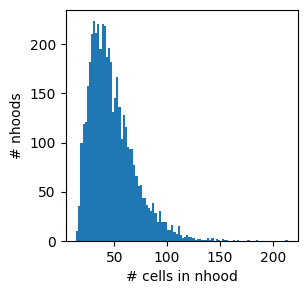

In [116]:
nhood_size = np.array(mdata["rna"].obsm["nhoods"].sum(0)).ravel()
plt.hist(nhood_size, bins=100)
plt.xlabel("# cells in nhood")
plt.ylabel("# nhoods");

In [117]:
mdata = milo.count_nhoods(mdata, sample_col="sample_id")

In [118]:
# Count number of cells per netreatment in each neighborhood
mdata["milo"].X.todense()

matrix([[ 2., 17.,  2., ..., 16.,  2.,  6.],
        [ 2.,  9.,  4., ..., 21.,  4.,  4.],
        [32., 16.,  6., ..., 18., 11.,  9.],
        [28., 15.,  7., ..., 14., 15.,  5.]],
       shape=(4, 4741), dtype=float32)

In [119]:
mdata["rna"].obs.treatment_label

AAACATACACCCAA    1
AAACATACCCCTCA    1
AAACATACCGGAGA    1
AAACATACTAACCG    1
AAACATACTCTTCA    1
                 ..
TTTGCATGAGCCTA    0
TTTGCATGCTAGCA    0
TTTGCATGCTGCAA    0
TTTGCATGGCTCCT    0
TTTGCATGTGGTAC    1
Name: treatment_label, Length: 65877, dtype: category
Categories (2, object): ['0', '1']

In [120]:
milo.da_nhoods(mdata, design="~treatment_label", solver='pydeseq2')

Using None as control genes, passed at DeseqDataSet initialization


Fitting size factors...
... done in 0.00 seconds.

Fitting dispersions...
... done in 1.49 seconds.

Fitting dispersion trend curve...
/home/icb/alessandro.palma/miniconda3/envs/scvi_env/lib/python3.11/site-packages/pydeseq2/dds.py:820: UserWarning: The dispersion trend curve fitting did not converge. Switching to a mean-based dispersion trend.
  self._fit_parametric_dispersion_trend(vst)
... done in 0.07 seconds.

/home/icb/alessandro.palma/miniconda3/envs/scvi_env/lib/python3.11/site-packages/pydeseq2/dds.py:548: UserWarning: As the residual degrees of freedom is less than 3, the distribution of log dispersions is especially asymmetric and likely to be poorly estimated by the MAD.
  self.fit_dispersion_prior()
Fitting MAP dispersions...
... done in 1.40 seconds.

Fitting LFCs...
... done in 1.07 seconds.

Calculating cook's distance...
... done in 0.00 seconds.

Replacing 0 outlier genes.

Running Wald tests...


Log2 fold change & Wald test p-value: treatment_label 1 vs 0
       baseMean  log2FoldChange     lfcSE      stat    pvalue      padj
0     15.069957        3.772437  0.972051  3.880902  0.000104  0.001862
1     13.941239        0.119683  0.738283  0.162111  0.871219  0.999378
2      4.590359        0.983343  0.956757  1.027788  0.304050  0.954887
3     10.107410       -0.344008  0.764490 -0.449984  0.652722  0.999378
4     15.439651        0.099107  0.723068  0.137065  0.890979  0.999378
...         ...             ...       ...       ...       ...       ...
4736  11.246473       -0.013039  0.765576 -0.017031  0.986412  0.999378
4737  18.365001        4.076082  0.973172  4.188451  0.000028  0.000958
4738  16.987455       -0.344612  0.706984 -0.487441  0.625946  0.999378
4739   7.646960        1.984909  0.913028  2.173985  0.029706  0.127224
4740   5.835125        0.348287  0.875798  0.397679  0.690867  0.999378

[4741 rows x 6 columns]


... done in 0.94 seconds.



In [121]:
mdata["milo"].var

,index_cell,kth_distance,logCPM,logFC,PValue,FDR,SpatialFDR
0,AAACGCACGGTACT,1.665295,15.069957,3.772437,0.000104,0.001862,0.001868
1,AAACTTGAGGAGCA,1.417195,13.941239,0.119683,0.871219,0.999378,0.999724
2,AAAGAGACGTTACG,1.843487,4.590359,0.983343,0.304050,0.954887,0.999724
3,AAAGATCTTATCTC,1.456541,10.107410,-0.344008,0.652722,0.999378,0.999724
4,AAAGTTTGTATTCC,1.292195,15.439651,0.099107,0.890979,0.999378,0.999724
...,...,...,...,...,...,...,...
4736,TTTAGAGAGAGACG,1.499688,11.246473,-0.013039,0.986412,0.999378,0.999724
4737,TTTAGCTGAACCGT,1.654078,18.365001,4.076082,0.000028,0.000958,0.000953
4738,TTTAGGCTTGGTGT,1.483719,16.987455,-0.344612,0.625946,0.999378,0.999724
4739,TTTATCCTGGTCAT,1.894518,7.646960,1.984909,0.029706,0.127224,0.135845


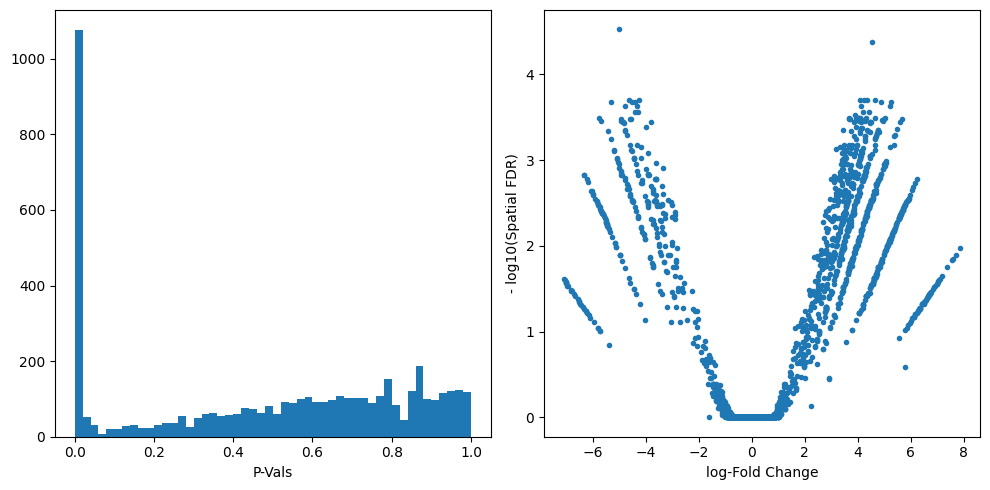

In [122]:
old_figsize = plt.rcParams["figure.figsize"]
plt.rcParams["figure.figsize"] = [10, 5]
plt.subplot(1, 2, 1)
plt.hist(mdata["milo"].var.PValue, bins=50)
plt.xlabel("P-Vals")
plt.subplot(1, 2, 2)
plt.plot(mdata["milo"].var.logFC, -np.log10(mdata["milo"].var.SpatialFDR), ".")
plt.xlabel("log-Fold Change")
plt.ylabel("- log10(Spatial FDR)")
plt.tight_layout()
plt.rcParams["figure.figsize"] = old_figsize

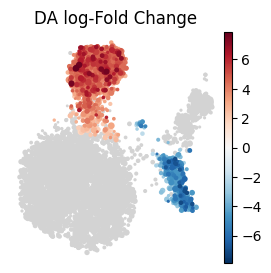

In [123]:
plt.rcParams["figure.figsize"] = [3, 3]
milo.build_nhood_graph(mdata)
milo.plot_nhood_graph(
    mdata,
    alpha=0.1,  # SpatialFDR level (1%)
    min_size=1,  # Size of smallest dot
)

# Relate results to single cells 

In [124]:
mdata["milo"].obs

,treatment_label,sample_id
0,0,0
1,0,1
2,1,2
3,1,3


In [125]:
mdata["milo"].var

,index_cell,kth_distance,logCPM,logFC,PValue,FDR,SpatialFDR,Nhood_size
0,AAACGCACGGTACT,1.665295,15.069957,3.772437,0.000104,0.001862,0.001868,64.0
1,AAACTTGAGGAGCA,1.417195,13.941239,0.119683,0.871219,0.999378,0.999724,57.0
2,AAAGAGACGTTACG,1.843487,4.590359,0.983343,0.304050,0.954887,0.999724,19.0
3,AAAGATCTTATCTC,1.456541,10.107410,-0.344008,0.652722,0.999378,0.999724,41.0
4,AAAGTTTGTATTCC,1.292195,15.439651,0.099107,0.890979,0.999378,0.999724,63.0
...,...,...,...,...,...,...,...,...
4736,TTTAGAGAGAGACG,1.499688,11.246473,-0.013039,0.986412,0.999378,0.999724,46.0
4737,TTTAGCTGAACCGT,1.654078,18.365001,4.076082,0.000028,0.000958,0.000953,78.0
4738,TTTAGGCTTGGTGT,1.483719,16.987455,-0.344612,0.625946,0.999378,0.999724,69.0
4739,TTTATCCTGGTCAT,1.894518,7.646960,1.984909,0.029706,0.127224,0.135845,32.0


In [126]:
mdata["milo"].varp["nhood_connectivities"]

<Compressed Sparse Column sparse matrix of dtype 'float32'
	with 534376 stored elements and shape (4741, 4741)>

In [127]:
mdata["rna"]

AnnData object with n_obs × n_vars = 65877 × 3000
    obs: 'celltype', 'leiden', 'treatment', 'sample_id', 'treatment_label', 'nhood_ixs_random', 'nhood_ixs_refined', 'nhood_kth_distance'
    var: 'Accession', 'Chromosome', 'End', 'Start', 'Strand', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
    uns: 'celltype_colors', 'hvg', 'leiden', 'leiden_colors', 'log1p', 'neighbors', 'pca', 'umap', 'treatment_colors', 'sample_id_colors', 'nhood_neighbors_key'
    obsm: 'X_pca', 'X_tsne', 'X_umap', 'nhoods'
    varm: 'PCs'
    layers: 'X_counts', 'spliced', 'unspliced'
    obsp: 'connectivities', 'distances'

In [128]:
nhoods = mdata["rna"].obsm["nhoods"]

In [129]:
nhoods.shape

(65877, 4741)

In [130]:
logFC = mdata["milo"].var["logFC"].values[:, None]

In [131]:
per_cell_fc = nhoods.dot(logFC) / nhoods.sum(1)

/tmp/ipykernel_1785758/3604824257.py:1: RuntimeWarning: invalid value encountered in divide
  per_cell_fc = nhoods.dot(logFC) / nhoods.sum(1)


In [140]:
np.isnan(per_cell_fc).sum() / per_cell_fc.shape[0]

np.float64(0.06278367260197033)

In [133]:
nhoods.sum(1)

matrix([[0.],
        [8.],
        [2.],
        ...,
        [4.],
        [1.],
        [4.]], shape=(65877, 1), dtype=float32)

In [134]:
nhoods.dot(logFC)

array([[ 0.        ],
       [-0.05749612],
       [-0.57271323],
       ...,
       [11.3132206 ],
       [-0.08776922],
       [-1.10574356]], shape=(65877, 1))

In [135]:
nhoods.sum(1)

matrix([[0.],
        [8.],
        [2.],
        ...,
        [4.],
        [1.],
        [4.]], shape=(65877, 1), dtype=float32)

In [136]:
per_cell_fc

matrix([[        nan],
        [-0.00718701],
        [-0.28635662],
        ...,
        [ 2.82830515],
        [-0.08776922],
        [-0.27643589]], shape=(65877, 1))

In [137]:
adata.obs["log_ratio"] = per_cell_fc

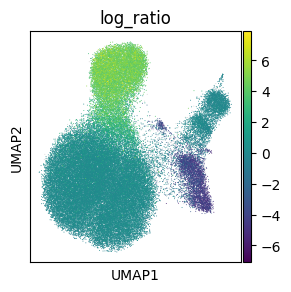

In [138]:
sc.pl.umap(adata, color="log_ratio")